In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Seed para reprodutibilidade dos testes de permutação
RNG = np.random.default_rng(42)


In [2]:
jobs = pd.read_parquet('db/jobs.parquet')
ratings = pd.read_parquet('db/ratings.parquet')


In [3]:
df = jobs.merge(ratings, how='inner', on='tconst')


In [4]:
contagem_de_filmes = df.groupby(by=['nconst'])['tconst'].count().rename('movieCount')


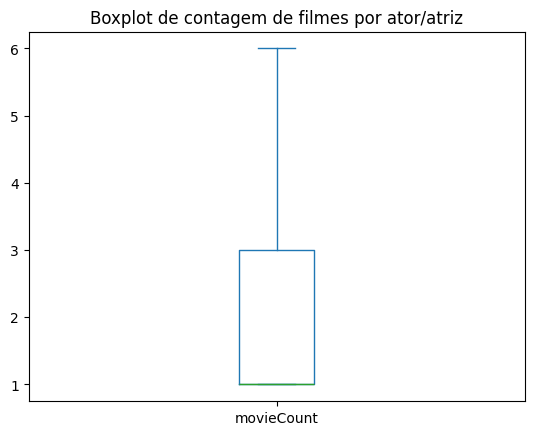

In [5]:
contagem_de_filmes.plot.box(showfliers=False)
plt.title('Boxplot de contagem de filmes por ator/atriz')
plt.show()


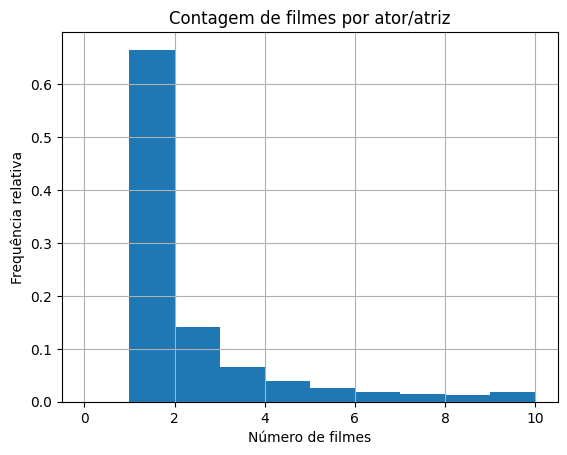

In [6]:
contagem_de_filmes.hist(bins=range(11), density=True)
plt.title('Contagem de filmes por ator/atriz')
plt.xlabel('Número de filmes')
plt.ylabel('Frequência relativa')
plt.show()


In [7]:
# Nota média de cada ator, ponderada pelo número de votos de cada filme
resultado = (
    df.groupby('nconst')
    .apply(
        lambda g: np.average(g['averageRating'], weights=g['numVotes']),
        include_groups=False
    )
    .rename('avgRatingAtor')
)


In [8]:
resultado = resultado.sort_values()


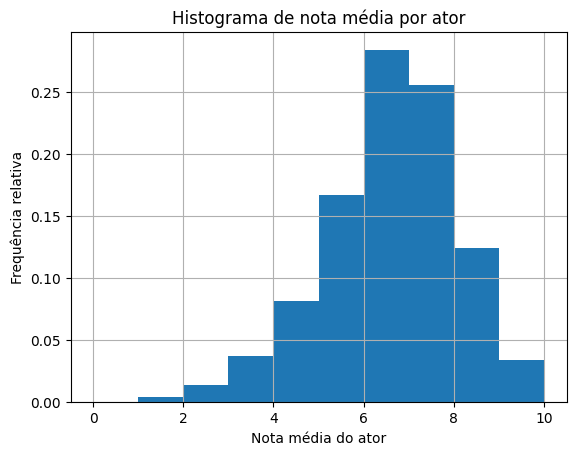

In [9]:
resultado.hist(bins=range(11), density=True)
plt.title('Histograma de nota média por ator')
plt.xlabel('Nota média do ator')
plt.ylabel('Frequência relativa')
plt.show()


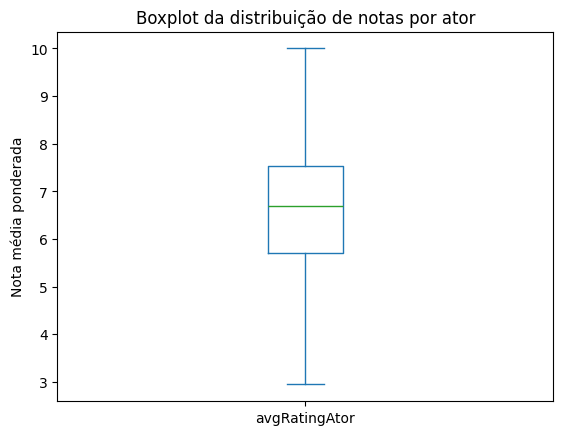

In [10]:
resultado.plot.box(showfliers=False)
plt.title('Boxplot da distribuição de notas por ator')
plt.ylabel('Nota média ponderada')
plt.show()


# A escolha de elenco influencia a nota do filme?

Para responder, criamos uma métrica de **"qualidade do elenco"** por filme: a média da nota histórica de cada ator/atriz do elenco principal, calculada de forma **leave-one-out** — ou seja, o histórico do ator usado para um filme X **não inclui** o próprio filme X, evitando vazamento de informação (o filme não pode "se prever" através do próprio resultado).

Depois testamos a correlação entre essa métrica (`castQualityScore`) e a nota real do filme (`averageRating`) usando **Spearman** (não exige linearidade nem normalidade) e validamos o p-valor com **teste de permutação**.

H0: não há correlação entre a qualidade histórica do elenco e a nota do filme.


In [11]:
# Soma e contagem de (rating * numVotes) por ator, para permitir o cálculo
# leave-one-out sem refazer a média do zero para cada filme.

df['weighted'] = df['averageRating'] * df['numVotes']

ator_totais = (
    df.groupby('nconst')
    .agg(
        soma_weighted=('weighted', 'sum'),
        soma_votos=('numVotes', 'sum')
    )
)

df = df.merge(ator_totais, on='nconst', how='left')


In [12]:
# Leave-one-out: remove a contribuição do próprio filme antes de calcular a média do ator

df['loo_soma_weighted'] = df['soma_weighted'] - df['weighted']
df['loo_soma_votos'] = df['soma_votos'] - df['numVotes']

# Se o ator só apareceu nesse filme, não há histórico (fica NaN)
df['loo_avgRatingAtor'] = np.where(
    df['loo_soma_votos'] > 0,
    df['loo_soma_weighted'] / df['loo_soma_votos'],
    np.nan
)


In [13]:
# Para cada filme, a métrica de qualidade do elenco é a média do loo_avgRatingAtor
# entre os atores/atrizes que têm histórico fora desse filme.

cast_quality = (
    df.dropna(subset=['loo_avgRatingAtor'])
    .groupby('tconst')
    .agg(
        castQualityScore=('loo_avgRatingAtor', 'mean'),
        castSize=('loo_avgRatingAtor', 'count'),
        averageRating=('averageRating', 'first')
    )
)

# Exigir pelo menos 1 ator com histórico (poderia ser maior, ex. >=2, para mais robustez)
cast_quality = cast_quality[cast_quality['castSize'] >= 1]

cast_quality.head()


,castQualityScore,castSize,averageRating
tconst,,,
tt0000007,4.772897,1,5.3
tt0000009,5.635208,1,5.3
tt0000014,8.100000,1,7.1
tt0000026,3.757265,2,5.6
tt0000036,4.482893,1,4.4


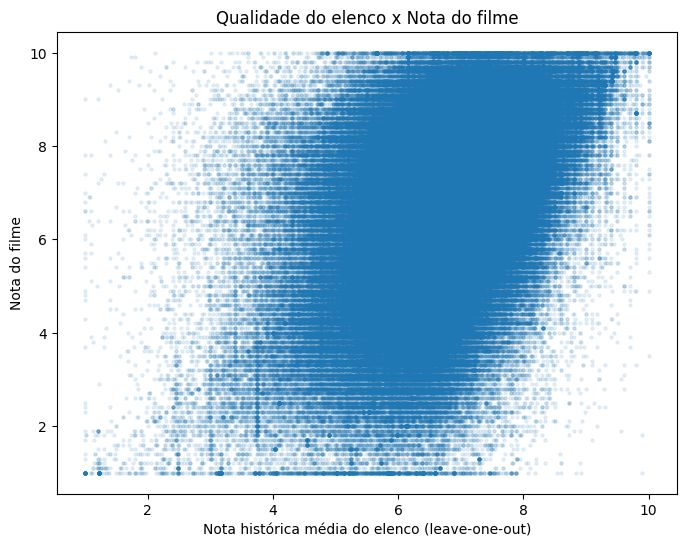

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(
    cast_quality['castQualityScore'],
    cast_quality['averageRating'],
    alpha=0.1,
    s=5
)
plt.xlabel('Nota histórica média do elenco (leave-one-out)')
plt.ylabel('Nota do filme')
plt.title('Qualidade do elenco x Nota do filme')
plt.show()


In [15]:
def permutation_test_correlation(x, y, n_perm=10_000, rng=RNG):
    """
    Teste de permutação para correlação de Spearman.
    H0: não há correlação entre x e y (a ordem de y é irrelevante).
    Retorna o rho observado e o p-valor bicaudal.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    observed_rho, _ = spearmanr(x, y)

    perm_rhos = np.empty(n_perm)

    for i in range(n_perm):
        shuffled_y = rng.permutation(y)
        perm_rhos[i], _ = spearmanr(x, shuffled_y)

    p_value = np.mean(np.abs(perm_rhos) >= np.abs(observed_rho))

    return observed_rho, p_value


In [16]:
rho_spearman, p_spearman_scipy = spearmanr(
    cast_quality['castQualityScore'],
    cast_quality['averageRating']
)

# Dataset grande: usamos uma amostra para o teste de permutação,
# já que o Spearman seria recalculado 10.000 vezes sobre o conjunto inteiro.
PERM_SAMPLE_SIZE = 20_000

cast_quality_sample = cast_quality.sample(
    n=min(PERM_SAMPLE_SIZE, len(cast_quality)),
    random_state=42
)

rho_perm, p_perm = permutation_test_correlation(
    cast_quality_sample['castQualityScore'],
    cast_quality_sample['averageRating']
)

print("="*60)
print("CORRELAÇÃO: QUALIDADE DO ELENCO x NOTA DO FILME")
print("="*60)
print(f"\nNúmero de filmes analisados (Spearman completo): {len(cast_quality)}")
print(f"Tamanho da amostra (teste de permutação): {len(cast_quality_sample)}")
print(f"\nSpearman rho (dataset completo) = {rho_spearman:.4f}")
print(f"p-valor (scipy, dataset completo) = {p_spearman_scipy:.5f}")
print(f"Spearman rho (amostra)          = {rho_perm:.4f}")
print(f"p-valor (permutação, 10.000, amostra) = {p_perm:.5f}")

if p_perm < 0.05:
    print("\nConclusão: Existe correlação estatisticamente significativa "
          "entre a qualidade histórica do elenco e a nota do filme.")
else:
    print("\nConclusão: Não foi encontrada correlação estatisticamente "
          "significativa entre a qualidade histórica do elenco e a nota do filme.")

print("\nObs: mesmo que significativo, um rho baixo (ex. < 0.2) indica "
      "que o efeito é fraco na prática, mesmo sendo estatisticamente real.")


CORRELAÇÃO: QUALIDADE DO ELENCO x NOTA DO FILME

Número de filmes analisados (Spearman completo): 1261015
Tamanho da amostra (teste de permutação): 20000

Spearman rho (dataset completo) = 0.4619
p-valor (scipy, dataset completo) = 0.00000
Spearman rho (amostra)          = 0.4618
p-valor (permutação, 10.000, amostra) = 0.00000

Conclusão: Existe correlação estatisticamente significativa entre a qualidade histórica do elenco e a nota do filme.

Obs: mesmo que significativo, um rho baixo (ex. < 0.2) indica que o efeito é fraco na prática, mesmo sendo estatisticamente real.
